# TP4 - Recherche de motif
!!! tip Rappels
Pensez à tester toutes vos fonctions, si des tests sont déjà présents ne vous privez pas de tester d'autres cas.\
Commenter votre code pour les parties complexes.
!!!

L'objectif de ce TP est de faire un algorithme qui va chercher un motif dans un texte, ou une sous-liste dans une liste.

!!! example Exemple
La liste `[1,3,5]` est une sous-liste de `[15,-12,1,3,5,19]`, ici par sous-liste on entend en un seul morceau.\
Ainsi, `[1,3,5]` n'est pas une sous-liste de `[1,2,3,4,5]`.

De même `"tar"` est contenu de `"il est tard"`, on dit donc que `"tar"` est un motif présent dans `"il est tard"`
!!!

!!! warning 
Les manipulations de listes et de chaînes de caractères étant proches, on demande d’écrire des codes qui vont fonctionner indifféremment sur les deux types de structure.
!!!

!!! info Algo
Voici la démarche naïve de recherche d’un motif dans un texte qui sera programmée :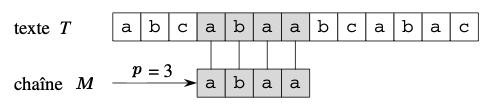
- On effectue la recherche avec une boucle qui va considérer toutes les positions `p` possibles pour le motif (on appelle position du mot l’indice de la 1ère lettre du mot).
    - Pour chaque position `p`, on teste si le motif apparait en position `p`
!!!

!!! abstract slice
Le terme anglais slice est associé à l’idée de découpage.\
En langage Python, cela permet d’extraire une tranche d’un objet itérable (liste ou string)
- `liste[start:end]` : renvoie une sous-liste de liste allant de l’index start (inclus) à l’index end (exclus)
- `liste[start:end:step]` : renvoie une sous-liste de liste allant de l’index start (inclus) à l’index end (exclus) avec un pas de step
- Si `start` est omis, il est considéré comme `0`
- Si `end` est omis, il est considéré comme `len(liste)`
- Si `step` est omis, il est considéré comme `1`
!!!

In [1]:
liste = [2,6,9,2,1,8,1]
print(liste[2:6])

[9, 2, 1, 8]


In [2]:
print(liste[:6])

[2, 6, 9, 2, 1, 8]


In [3]:
print(liste[4:])

[1, 8, 1]


In [4]:
print(liste[::2])

[2, 9, 1, 1]


!!! question Question 1
En notant `t` la longueur du **texte** et `m` la longueur du **motif**, quelles sont les valeurs de l'indice `i` à considérer pour tester toutes les positions possibles du `motif` dans le `texte`? 

Comment récupérer à l’aide d’un slice le sous-mot de `texte` qui se trouve à la position `i` et qu’il faudra comparer avec `motif`?
!!!

!!! question Question 2
Ecrire une fonction `recherche_motif_1(motif, texte)` qui, en utilisant les slices, étant donnés deux chaînes de caractères (ou deux listes) `motif` et `texte`, renvoie `True` si `motif` est présent dans `texte` et `False` sinon.
!!!

In [1]:
def recherche_motif_1(motif, texte):
    for i in range(len(texte)-len(motif)+1):
        if motif == texte[i:i+len(motif)]:
            return True
    return False

In [2]:
print(recherche_motif_1('tard', 'il est tard'))
# True

True


In [3]:
print(recherche_motif_1([1,3,5], [15,-12,1,3,5,19]))
# True

True


In [4]:
print(recherche_motif_1([1,3,5], [1,2,3,4,5]))
# False

False


!!! question Question 3
Ecrire une fonction `recherche_motif_2(motif, texte)` qui a le même comportement mais n'utilise pas les slices.
!!!

In [5]:
def recherche_motif_2(motif, texte):
    for i in range(len(texte)-len(motif)+1):
        for j in range(len(motif)):
            if motif[j] != texte[i+j]:
                break
            elif j == len(motif)-1:
                return True
    return False

In [6]:
print(recherche_motif_2('tard', 'il est tard'))
# True

True


In [7]:
print(recherche_motif_2([1,3,5], [15,-12,1,3,5,19]))
# True

True


In [8]:
print(recherche_motif_2([1,3,5], [1,2,3,4,5]))
# False

False


!!! question Question 4
Ecrire une fonction `positions_motif(motif, texte)` qui renvoie la liste, éventuellement vide, des positions du motif dans le texte.
!!!

In [7]:
def positions_motif(motif, texte):
    res = []
    for i in range(len(texte)-len(motif)+1):
        if motif == texte[i:i+len(motif)]:
            res.append(i)
    return res

In [8]:
print(positions_motif([1,3,5], [15,-12,1,3,5,19]))
# [2]

[2]


In [9]:
print(positions_motif('tar', 'il est tard'))
# [7]

[7]


In [10]:
print(positions_motif('ab', 'abracadabra'))
# [0, 7]

[0, 7]


!!! question Question 5
Combien de fois apparait le motif "son" dans le texte suivant.
!!!

In [13]:
extrait = """Anton Voyl n'arrivait pas à dormir. Il alluma. Son Jaz marquait
 minuit vingt. Il poussa un profond soupir, s'assit dans son lit, 
 s'appuyant sur son polochon. Il prit un roman, il l'ouvrit, il lut; 
 mais il n'y saisissait qu'un imbroglio confus, il butait à tout instant 
 sur un mot dont il ignorait la signification.\n Il abandonna son roman 
 sur son lit. Il alla à son lavabo; il mouilla un gant qu'il passa sur 
 son front, sur son cou.\n Son pouls battait trop fort. Il avait chaud. 
 Il ouvrit son vasistas, scruta la nuit. Il faisait doux. Un bruit 
 indistinct montait du faubourg. Un carillon, plus lourd qu'un glas, plus 
 sourd qu'un tocsin, plus profond qu'un bourdon, non loin, sonna trois 
 coups. Du canal Saint-Martin, un clapotis plaintif signalait un chaland 
 qui passait. Sur l'abattant du vasistas, un animal au thorax indigo, à 
 l'aiguillon safran, ni un cafard, ni un charançon, mais plutôt un 
 artison, s'avançait, traînant un brin d'alfa. Il s'approcha, voulant 
 l'aplatir d'un coup vif, mais l'animal prit son vol, disparaissant dans 
 la nuit avant qu'il ait pu l'assaillir."""

In [14]:
print(len(positions_motif('son', extrait)))

11


!!! question Question 6
Déterminer la complexité dans le pire cas de la fonction `recherche_motif_2(motif, texte)`? Est-elle différente de `recherche_motif_1(motif, texte)` ?
!!!

On pose $t = |texte|$ et $m = |motif|$\
$O((t-m+1)*m) = O((t-m)*m) = O(t*m - m^2) = O(t*m)$ (car on suppose m<t)\
La complexité de `recherche_motif_1` est la même car la création du slice et la comparaison de 2 listes (`texte[i:i+m]` et `motif`) est en $O(m)$.

## Exercice bonus : Algorithme de Boyer-Moore

!!! info Principe de l'algorithme 
L’algorithme de Boyer–Moore utilise un prétraitement du motif `m` à chercher dans un texte `t` pour accélérer la recherche. Le principe de l’algorithme est le suivant :
- On va tester l’occurrence du motif `m` dans le texte `t` à des positions `i` de plus en plus grandes, en partant de `i = 0`. (Comme dans l'exercice précédent).
- Pour une position `i` donnée, on va comparer les caractères de `m` et de `t` de la **droite vers la gauche**, c’est-à-dire en comparant d’abord `m[M−1]` et `t[i+M−1]`, puis `m[M−2]` et `t[i+M−2]`, etc. Il s’agit là du sens inverse de celui utilisé dans l'exercice précédent. Le changement peut paraître anecdotique, mais en pratique il permet d’avancer plus vite dans certains cas (dont nous discuterons plus loin).
- Si tous les caractères coïncident, on a trouvé une occurrence. Sinon, soit `j` l’indice de la première différence, c’est-à-dire le plus grand entier tel que `0 ⩽ j < M` et `m[j] != t[i + j]`. Appelons `c` le caractère `t[i + j]`.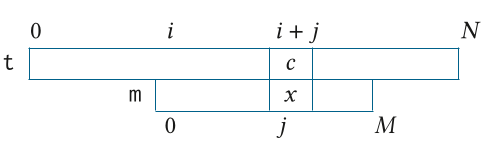

L’idée de l’algorithme de Boyer–Moore consiste à augmenter alors la valeur de `i` de : 
- la grandeur `j − k` où `k` est le plus grand entier tel que `0 ⩽ k < j` et `m[k] = c`, si un tel `k` existe (de manière à amener un caractère `c` de `m` sous le caractère `t[i + j]`).Autrement dit à la plus position de `c` la plus à droite avant `j` dans le motif,
- la grandeur `j + 1` sinon.
!!!

!!! example Exemple

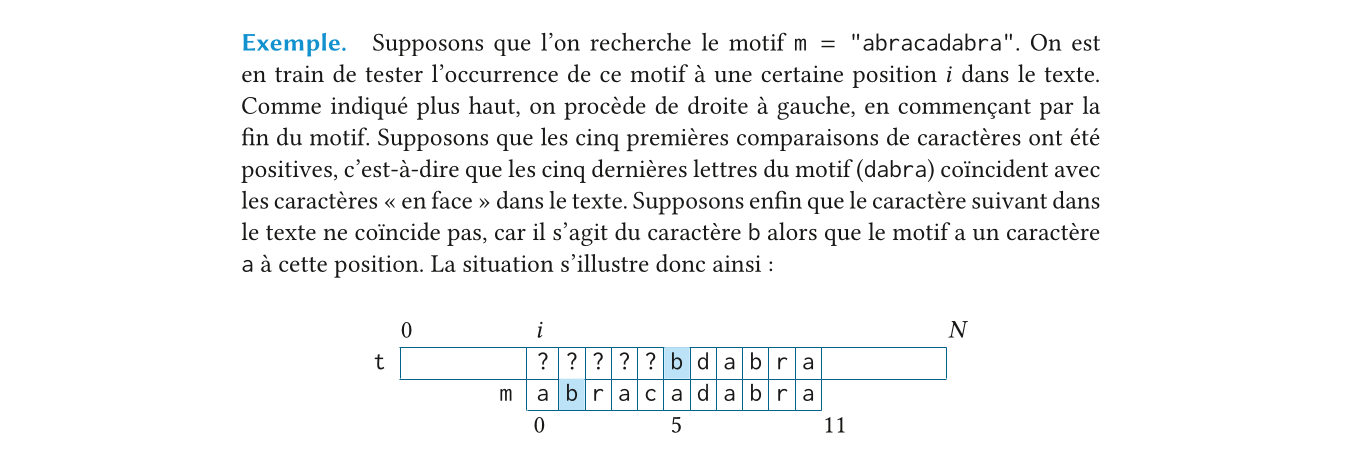

Il faut décaler le motif de `j − 1 = 4` positions vers la droite, car le `'b'` le plus à droite dans notre motif qui est avant l'indice `j` est en position 1. Cela a pour effet d’amener le caractère `'b'` en deuxième position dans le motif sous le caractère `'b'` du texte.

Si en revanche le caractère du texte avait été `'z'`, comme il n’y a pas d’occurrence de `'z'` dans les cinq premiers caractères du motif, on aurait alors décalé le motif de `j + 1 = 6` positions vers la droite.
!!!

!!! tip Tips : dérouler l'algorithme 
Aller sur ce site dans Algorithme > Boyer-Moore Variante 1ere table https://physalgo.fr/recherchetextuelle/index.html
!!!

!!! question Question 1 
Écrivez la fonction `decalage(motif, j, c)` qui calcule de combien doit se décaler `i` en sachant que `texte[i+j] != motif[j]`.\
Le décalage est :
- soit `j - k`, où `k` est l'occurence la plus à droite de `c` dans `motif` avant `j` (`0 ⩽ k < j`)
- soit `j +1` si `c` n'apparait pas dans `motif[0:j[`
!!!

In [3]:
def decalage(motif, j, c):
    k = j-1
    while k >= 0 and motif[k] != c:
        k-=1
    if k <= 0:
        return j+1
    return j-k

In [4]:
print(decalage("abracadabra", 5, 'b'))
print(decalage("abracadabra", 5, 'z'))

4
6


!!! question Question 2
Écrivez la fonction `boyer_moore_1(motif, texte)` qui renvoie la liste des occurences de `motif` dans `texte` grâce à l'algorithme de Boyer-Moore et de votre fonction `decalage(motif, j, c)`.

On parcourt `texte` de gauche à droite via un indice `i`, et `motif` de droite à gauche avec un indice `j`.
Tant qu'on a texte[i+j] == motif[j] on continue :
- si on a trouvé l'occurence on l'ajoute à la liste de résultat et on incrémente i de 1
- sinon on incrémente i du résultat de la fonction de décalage.
!!!

In [5]:
def boyer_moore_1(motif, texte):
    i = 0
    res = []
    while i <= len(texte)-len(motif):
        j = len(motif)-1
        while j >= 0 and texte[i+j] == motif[j]:
            j-=1
        if j < 0:
            res.append(i)
            i+=1
        else:
            i += decalage(motif, j, texte[i+j])
    return res

In [6]:
print(boyer_moore_1('ab', 'abracadabra'))

[0, 7]


!!! info Table de décalage 
Plutôt que de rechercher un tel `k` à chaque fois, on peut précalculer une table de décalages contenant, à la case indexée par l’entier `j` et le caractère `c`, le plus grand entier `k` tel que `0 ⩽ k < j` et `m[k] = c` s’il existe, et rien sinon.
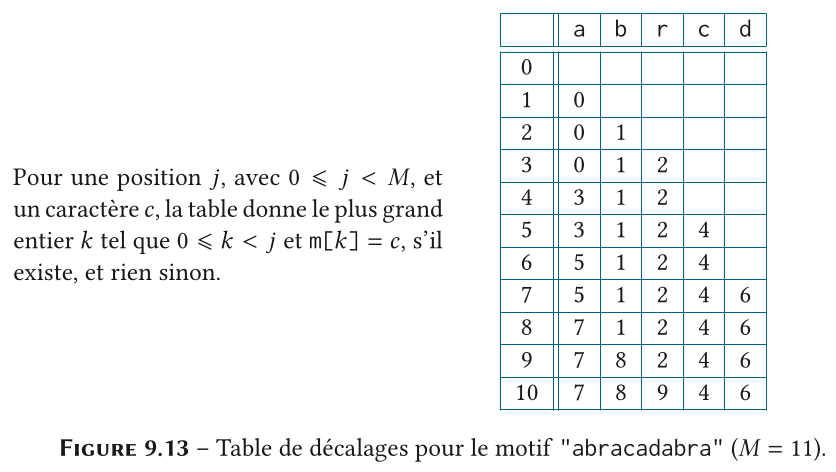
!!!

!!! question Question 3
Écrivez une fonction `table_decalage(motif)` qui prend un motif et renvoie sa table de décalage.

Cette table est en fait une liste de dictionnaire, chaque ligne représente `j`, chaque clé d'un dictionnaire représente `c`.
Il suffit de parcourir pour `motif[0:j[` la ligne `j` et chercher l'indice l'indice `k` le plus grand dans `motif[0:j[`. Et faire celà pour chaque ligne.
!!!

In [27]:
def tale_decalage(motif):
    table = [{} for _ in range(len(motif))]
    for j in range(len(motif)):
        for k in range(j):
             table[j][motif[k]] = k
    return table

In [28]:
table = tale_decalage("abracadabra")
print(table[5]['b'])

for ligne in table:
    print(ligne)

1
{}
{'a': 0}
{'a': 0, 'b': 1}
{'a': 0, 'b': 1, 'r': 2}
{'a': 3, 'b': 1, 'r': 2}
{'a': 3, 'b': 1, 'r': 2, 'c': 4}
{'a': 5, 'b': 1, 'r': 2, 'c': 4}
{'a': 5, 'b': 1, 'r': 2, 'c': 4, 'd': 6}
{'a': 7, 'b': 1, 'r': 2, 'c': 4, 'd': 6}
{'a': 7, 'b': 8, 'r': 2, 'c': 4, 'd': 6}
{'a': 7, 'b': 8, 'r': 9, 'c': 4, 'd': 6}


!!! question Question 4
Écrivez la fonction `boyer_moore_2(motif, texte)` qui fait commen la fonction `boyer_moore_2()` mais en utilisant la table de decalage.\
Attention à gérer le cas où la lettre n'est pas présente dans la table à la ligne `j`.
!!!

In [29]:
def boyer_moore_2(motif, texte):
    i = 0
    res = []
    table = tale_decalage(motif)
    while i < len(texte)-len(motif):
        j = len(motif)-1
        while j >= 0 and texte[i+j] == motif[j]:
            j-=1
        if j < 0:
            res.append(i)
            i+=1
        else:
            c = texte[i+j]
            if c in table[j]:
                i += j - table[j][c]
            else:
                i += j + 1
    return res

In [30]:
print(boyer_moore_2('ab', 'abracadabra'))

[0, 7]


!!! question Question 5
Comparez le temps d'execution de vos fonction `positions_motif()`, `boyer_moore_1()` et `boyer_moore_2()`.
!!!

In [31]:
import time 

nom_fichier = 'Edmond%20About%20LE%20ROI%20DES.txt'
fichier = open(nom_fichier,'r')
lignes = fichier.readlines()
livre = "".join(lignes)
fichier.close()


temps_debut = time.perf_counter()
res = len(positions_motif('Simons', livre))
temps_fin = time.perf_counter()
print("Version naïve                  :", temps_fin - temps_debut, "| resultat : ", res)

temps_debut = time.perf_counter()
boyer_moore_1('Simons', livre)
temps_fin = time.perf_counter()
print("Version Boyer-Moore sans table :", temps_fin - temps_debut, "| resultat : ", res)

temps_debut = time.perf_counter()
boyer_moore_2('Simons', livre)
temps_fin = time.perf_counter()
print("Version Boyer-Moore avec table :", temps_fin - temps_debut, "| resultat : ", res)



Version naïve                  : 0.1286999989999984 | resultat :  109
Version Boyer-Moore sans table : 0.09410000000000096 | resultat :  109
Version Boyer-Moore avec table : 0.06310000099999868 | resultat :  109
